In [1]:
import pandas as pd                                                                          
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df = pd.read_csv(r"C:\Users\prati\Downloads\Multiple Linear Regression\ToyotaCorolla - MLR.csv")
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [3]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [4]:
df.dtypes

Price         int64
Age_08_04     int64
KM            int64
Fuel_Type    object
HP            int64
Automatic     int64
cc            int64
Doors         int64
Cylinders     int64
Gears         int64
Weight        int64
dtype: object

In [5]:
df.isnull().sum()


Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [6]:
print("""No null values""")

No null values


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


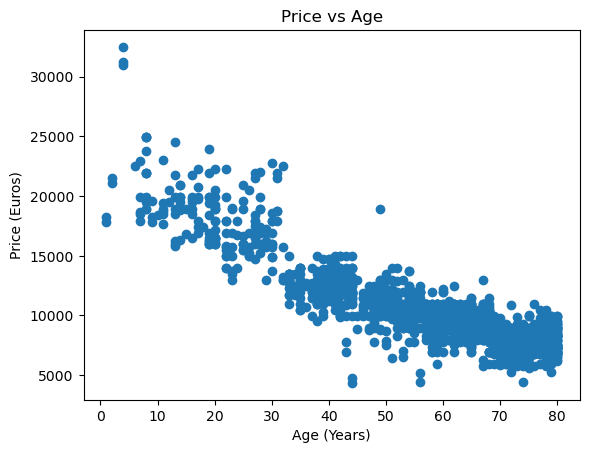

Explanation:
A clear downward (negative) trend
As Age increases, Price decreases
Newer cars (low age) have:
Higher prices
More variability
Older cars cluster at:
Lower prices
Less variability


In [8]:
plt.figure()
plt.scatter(df["Age_08_04"],df["Price"])
plt.xlabel("Age (Years)")
plt.ylabel("Price (Euros)")
plt.title("Price vs Age")
plt.show()
print("""Explanation:
A clear downward (negative) trend
As Age increases, Price decreases
Newer cars (low age) have:
Higher prices
More variability
Older cars cluster at:
Lower prices
Less variability""")

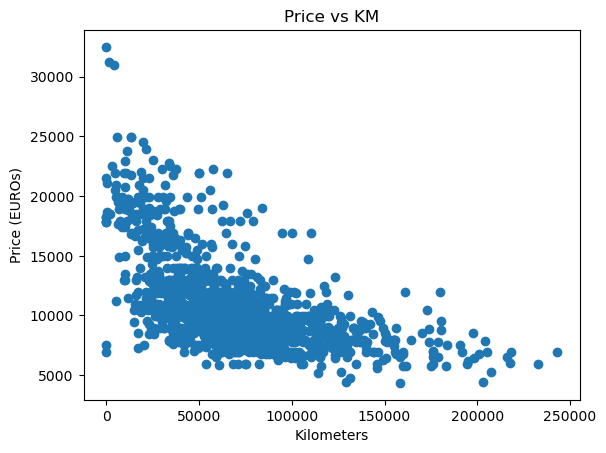

Explanation:
Another negative relationship
As kilometers driven increase, price decreases
High-price cars mostly appear at low mileage
At high mileage:
Prices converge to lower values
Variability decreases
Relationships appear approximately linear → suitable for linear regression


In [9]:
plt.figure()
plt.scatter(df["KM"], df["Price"])
plt.xlabel("Kilometers")
plt.ylabel("Price (EUROs)")
plt.title("Price vs KM")
plt.show()
print("""Explanation:
Another negative relationship
As kilometers driven increase, price decreases
High-price cars mostly appear at low mileage
At high mileage:
Prices converge to lower values
Variability decreases
Relationships appear approximately linear → suitable for linear regression""")

In [10]:
df_encoded = pd.get_dummies(df, columns=["Fuel_Type"], drop_first=True)
print("""Explanation:
Regression models cannot handle categorical text
FuelType is nominal (Petrol, Diesel, CNG)
One-hot encoding converts it into numeric form
drop_first=True avoids dummy variable trap""")
X = df_encoded.drop("Price", axis=1)
y = df_encoded["Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Explanation:
Regression models cannot handle categorical text
FuelType is nominal (Petrol, Diesel, CNG)
One-hot encoding converts it into numeric form
drop_first=True avoids dummy variable trap


In [11]:
lr_full = LinearRegression()
lr_full.fit(X_train, y_train)
y_pred_full = lr_full.predict(X_test)

In [12]:
selected_features = ["Age_08_04", "KM", "HP", "Weight"]
X_red = df_encoded[selected_features]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_red, y, test_size=0.2, random_state=42
)

lr_reduced = LinearRegression()
lr_reduced.fit(Xr_train, yr_train)

yr_pred = lr_reduced.predict(Xr_test)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
ridge_cv = GridSearchCV(
    Ridge(),
    {"alpha": [0.01, 0.1, 1, 10, 100]},
    scoring="r2",
    cv=5
)

ridge_cv.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_cv.best_estimator_.predict(X_test_scaled)

In [15]:
lasso_cv = GridSearchCV(
    Lasso(max_iter=5000),
    {"alpha": [0.01, 0.05, 0.1, 0.5, 1]},
    scoring="r2",
    cv=5
)

lasso_cv.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_cv.best_estimator_.predict(X_test_scaled)

In [16]:
print("""Explanation:
Full Multiple Linear Regression Model:
Uses all available predictors
Acts as a baseline model
Helps understand the overall relationships
Identification:
R² = 0.83
Explains 83% of price variability
Coefficients show:
Age & KM → negative impact
HP & Weight → positive impact

Conclusion:
The model performs well but may contain redundant variables.

Reduced Linear Regression Model:
Some predictors add noise or multicollinearity
We keep only most influential variables
Age, KM, HP, Weight
Identification:
R² = 0.85 (highest)
RMSE = lowest
Simpler and more interpretable model

Conclusion:
Removing weak variables improves performance and interpretability.

Standardization:
Ridge and Lasso penalize coefficients
Variables have different scales (KM vs HP)
We get Mean = 0, Std = 1 for all predictors


Ridge Regression (L2 Regularization):
Handles multicollinearity
Shrinks coefficients
Keeps all predictors
Identification:
Slightly lower R² than reduced model
More stable coefficients
Better robustness

Conclusion:
Ridge trades a small amount of accuracy for stability and robustness.

Lasso Regression (L1 Regularization):
Performs feature selection
Shrinks some coefficients to zero
Helps identify irrelevant predictors
Identification:
Similar performance to full model
No major feature elimination here

Conclusion:
Since predictors are already meaningful, Lasso offers limited advantage.""")

Explanation:
Full Multiple Linear Regression Model:
Uses all available predictors
Acts as a baseline model
Helps understand the overall relationships
Identification:
R² = 0.83
Explains 83% of price variability
Coefficients show:
Age & KM → negative impact
HP & Weight → positive impact

Conclusion:
The model performs well but may contain redundant variables.

Reduced Linear Regression Model:
Some predictors add noise or multicollinearity
We keep only most influential variables
Age, KM, HP, Weight
Identification:
R² = 0.85 (highest)
RMSE = lowest
Simpler and more interpretable model

Conclusion:
Removing weak variables improves performance and interpretability.

Standardization:
Ridge and Lasso penalize coefficients
Variables have different scales (KM vs HP)
We get Mean = 0, Std = 1 for all predictors


Ridge Regression (L2 Regularization):
Handles multicollinearity
Shrinks coefficients
Keeps all predictors
Identification:
Slightly lower R² than reduced model
More stable coefficients
Bet

In [17]:
def regression_metrics(y_true, y_pred, tolerance=1500):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

results = pd.DataFrame({
    "Model": [
        "Full Linear Regression",
        "Reduced Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "R2": [
        regression_metrics(y_test, y_pred_full)["R2"],
        regression_metrics(yr_test, yr_pred)["R2"],
        regression_metrics(y_test, y_pred_ridge)["R2"],
        regression_metrics(y_test, y_pred_lasso)["R2"]
    ],
    "RMSE": [
        regression_metrics(y_test, y_pred_full)["RMSE"],
        regression_metrics(yr_test, yr_pred)["RMSE"],
        regression_metrics(y_test, y_pred_ridge)["RMSE"],
        regression_metrics(y_test, y_pred_lasso)["RMSE"]
    ],
    "MAE": [
        regression_metrics(y_test, y_pred_full)["MAE"],
        regression_metrics(yr_test, yr_pred)["MAE"],
        regression_metrics(y_test, y_pred_ridge)["MAE"],
        regression_metrics(y_test, y_pred_lasso)["MAE"]
    ]
})

results


,Model,R2,RMSE,MAE
0,Full Linear Regression,0.834889,1484.265415,990.887274
1,Reduced Linear Regression,0.850607,1411.850209,1001.201747
2,Ridge Regression,0.841678,1453.431661,993.738643
3,Lasso Regression,0.835118,1483.235687,991.017466


In [18]:
print("""Explanation:
Reduced Linear Regression is best:
Highest R²
Lowest RMSE
Differences in MAE are small, models are consistent""")

Explanation:
Reduced Linear Regression is best:
Highest R²
Lowest RMSE
Differences in MAE are small, models are consistent


In [19]:
X_vif = X.select_dtypes(include=[np.number])

vif_df = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_df.sort_values("VIF", ascending=False)


,Feature,VIF
6,Cylinders,1378.328904
0,Age_08_04,1.909676
1,KM,1.679142
8,Weight,1.664910
2,HP,1.218066
5,Doors,1.155484
4,cc,1.150898
7,Gears,1.109188
3,Automatic,1.047677


In [20]:
print("""Explanation:
Cylinders (VIF = 1378)
Interpretation:
Extremely high VIF = severe multicollinearity
Cylinders is almost perfectly predicted by other variables
Identification:
Nearly all cars in the dataset have 4 cylinders
Very little variation
Strong overlap with:
Engine capacity (cc)
Horsepower (HP)
Weight
Implication
Coefficient becomes unstable or meaningless
Adds no predictive value

Conclusion:
Remove Cylinders from the model or rely on Ridge regression to control its effect

All Other Variables (VIF < 2)
Interpretation:
Very low multicollinearity
Each variable contributes unique information
Coefficients are stable and interpretable
Examples
Age (1.91): Slight correlation with KM (expected)
KM (1.68): Mild overlap with Age
HP / cc / Weight: Slight engineering-related correlation, but acceptable
Conclusion:
No corrective action needed for these variables.

Overall Conclusion from VIF Analysis
The model is mostly free from multicollinearity
Only Cylinders is problematic
Conclusion:
Removing it would-
Improve coefficient stability
Simplify interpretation
Not reduce model performance""")

Explanation:
Cylinders (VIF = 1378)
Interpretation:
Extremely high VIF = severe multicollinearity
Cylinders is almost perfectly predicted by other variables
Identification:
Nearly all cars in the dataset have 4 cylinders
Very little variation
Strong overlap with:
Engine capacity (cc)
Horsepower (HP)
Weight
Implication
Coefficient becomes unstable or meaningless
Adds no predictive value

Conclusion:
Remove Cylinders from the model or rely on Ridge regression to control its effect

All Other Variables (VIF < 2)
Interpretation:
Very low multicollinearity
Each variable contributes unique information
Coefficients are stable and interpretable
Examples
Age (1.91): Slight correlation with KM (expected)
KM (1.68): Mild overlap with Age
HP / cc / Weight: Slight engineering-related correlation, but acceptable
Conclusion:
No corrective action needed for these variables.

Overall Conclusion from VIF Analysis
The model is mostly free from multicollinearity
Only Cylinders is problematic
Conclusion:
R

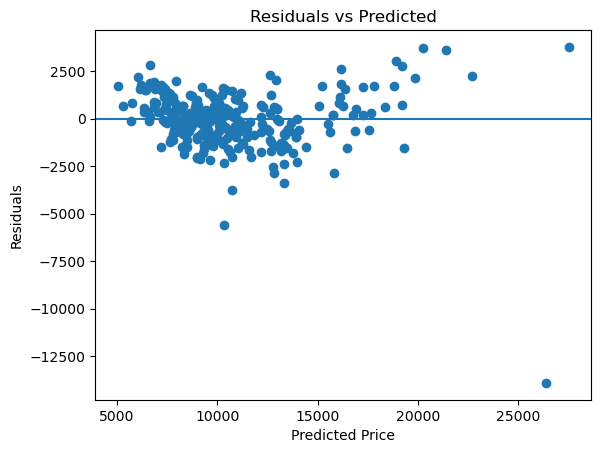

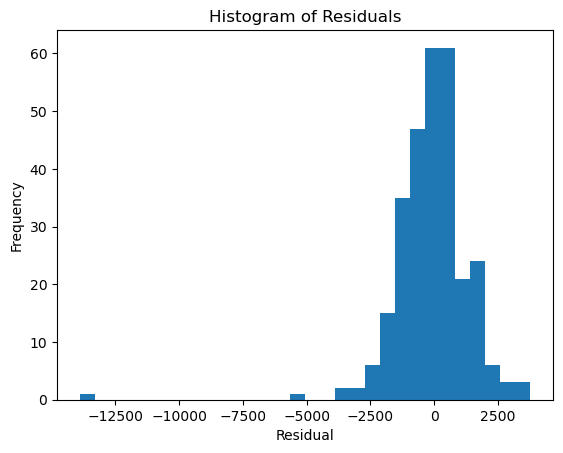

Explanation:
Residuals are randomly scattered
No strong patterns
Errors approximately normally distributed
Conclusion:
Model assumptions are reasonably satisfied.


In [21]:
residuals = y_test - y_pred_full

plt.scatter(y_pred_full, residuals)
plt.axhline(0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

print("""Explanation:
Residuals are randomly scattered
No strong patterns
Errors approximately normally distributed
Conclusion:
Model assumptions are reasonably satisfied.""")

In [22]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_full.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
10,Fuel_Type_Petrol,1.370809e+03
7,Gears,5.516007e+02
3,Automatic,1.488309e+02
8,Weight,2.588496e+01
2,HP,1.403948e+01
6,Cylinders,-8.242296e-13
1,KM,-1.623141e-02
4,cc,-3.037219e-02
5,Doors,-6.031097e+01
9,Fuel_Type_Diesel,-6.854876e+01


In [23]:
print("""Explanation:
Fuel_Type_Petrol → +1370.81
Interpretation:
Petrol cars are priced €1371 higher than the baseline fuel type.
What is the baseline?
Because of drop_first=True, one fuel category is dropped.
The dropped category (baseline) is CNG.
Meaning
Petrol cars cost about €1371 more than CNG cars, on average.
This makes sense since CNG cars are usually cheaper in resale markets.

Gears → +551.60
Interpretation:
Each additional gear increases the car price by €552, on average.
Reason
More gears usually indicate:
Better driving comfort
Newer or higher-end models
Strong positive impact, economically sensible.

Automatic → +148.83
Interpretation:
Automatic cars are priced €149 higher than manual cars.
Insight:
Automatic transmission adds convenience
Effect is positive but small, likely due to:
Market dominance of manual cars in the dataset

Weight → +25.88
Interpretation:
For every 1 kg increase, price increases by €25.9.
Practical meaning
Heavier cars often have:
Better build quality
Larger engines
More features
Weight indirectly captures vehicle robustness.

HP (Horse Power) → +14.04
Interpretation:
Each additional horsepower increases price by €14.
Insight:
Higher power = better performance
Impact is positive but moderate
Expected direction and magnitude.

Cylinders → = 0 (−8.24 × 10⁻¹³)
Interpretation:
Effect is essentially zero.
Insight:
Almost all cars have 4 cylinders
No variation → no explanatory power

This confirms high multicollinearity / redundancy
Should be removed from the model

KM → −0.0162
Interpretation:
Each additional kilometer reduces price by €0.016
Every 10,000 km reduces price by about €162
Mileage depreciation is clearly captured.

cc (Engine Capacity) → −0.0304
Interpretation:
Each additional cc reduces price slightly by €0.03
Insight:
Engine capacity overlaps with:
HP
Weight
Indicates multicollinearity effect
Not economically meaningful alone

Doors → −60.31
Interpretation:
Each additional door reduces price by €60.
Possible reason
2–3 door models are often sportier
5-door models are more common, less premium
Dataset-specific effect.

Fuel_Type_Diesel → −68.55
Interpretation:
Diesel cars are priced €69 lower than CNG cars.
Insight:
Contrary to some markets
Reflects dataset-specific pricing trends
Sign is data-driven, not universal.

Age_08_04 → −120.83
Interpretation:
Each additional month of age reduces price by €121
Approximately €1450 per year depreciation
This is the strongest negative effect""")

Explanation:
Fuel_Type_Petrol → +1370.81
Interpretation:
Petrol cars are priced €1371 higher than the baseline fuel type.
What is the baseline?
Because of drop_first=True, one fuel category is dropped.
The dropped category (baseline) is CNG.
Meaning
Petrol cars cost about €1371 more than CNG cars, on average.
This makes sense since CNG cars are usually cheaper in resale markets.

Gears → +551.60
Interpretation:
Each additional gear increases the car price by €552, on average.
Reason
More gears usually indicate:
Better driving comfort
Newer or higher-end models
Strong positive impact, economically sensible.

Automatic → +148.83
Interpretation:
Automatic cars are priced €149 higher than manual cars.
Insight:
Automatic transmission adds convenience
Effect is positive but small, likely due to:
Market dominance of manual cars in the dataset

Weight → +25.88
Interpretation:
For every 1 kg increase, price increases by €25.9.
Practical meaning
Heavier cars often have:
Better build quality
Larg

In [24]:
print("""Explanation:
1)Normalization

Definition:
Normalization rescales data to a fixed range, usually [0, 1].


Standardization

Definition:
Standardization rescales data so that it has:
Mean = 0
Standard Deviation = 1


Why Standardization Was Used in Our Model
Ridge and Lasso apply penalties on coefficients
Features like KM and HP have very different scales
Without standardization, large-scale features dominate
Result:
Fair penalty application and stable coefficients.

2)What is Multicollinearity?
Multicollinearity occurs when independent variables are highly correlated, causing:
Unstable coefficients
Large standard errors
Poor interpretability

What we did in our Analysis
Calculated VIF
Identified Cylinders with very high VIF
Removed or controlled it using Ridge regression
This improved model stability without losing accuracy.""")

Explanation:
1)Normalization

Definition:
Normalization rescales data to a fixed range, usually [0, 1].


Standardization

Definition:
Standardization rescales data so that it has:
Mean = 0
Standard Deviation = 1


Why Standardization Was Used in Our Model
Ridge and Lasso apply penalties on coefficients
Features like KM and HP have very different scales
Without standardization, large-scale features dominate
Result:
Fair penalty application and stable coefficients.

2)What is Multicollinearity?
Multicollinearity occurs when independent variables are highly correlated, causing:
Unstable coefficients
Large standard errors
Poor interpretability

What we did in our Analysis
Calculated VIF
Identified Cylinders with very high VIF
Removed or controlled it using Ridge regression
This improved model stability without losing accuracy.
